In [12]:
%pip install numpy
%pip install scipy
%pip install matplotlib
%pip install sympy

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import sympy as sp

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Осциллятор Ван-дер-поля: $$ x'' - \mu(1-x^2)x' + x = 0 $$

In [13]:
def vdf(t, state, mu):
    '''
    x1 = x
    x2 = x'
    '''
    x, dx = state
    ddx = mu * (1 - x**2) * dx - x

    return [dx, ddx]

# Положение равновесия

In [14]:
x, dx, mu = sp.symbols('x dx mu')

eq1 = sp.Eq(dx, 0)
eq2 = sp.Eq(mu * (1 - x**2) * dx - x, 0)

equilibrium = sp.solve((eq1, eq2), (x, dx))

equilibrium

[(0, 0)]

# Исследование на устойчивость

In [15]:
from IPython.display import display

x, dx, mu = sp.symbols('x dx mu')

f1 = dx
f2 = mu * (1 - x**2) * dx - x

F = sp.Matrix([f1, f2])
J = F.jacobian([x, dx])

J0 = J.subs({x: 0, dx: 0})

eigenvalues = J0.eigenvals()

display(J0)
eigenvalues = list(J0.eigenvals().keys())

for value in eigenvalues:
    display(value)

Matrix([
[ 0,  1],
[-1, mu]])

mu/2 - sqrt((mu - 2)*(mu + 2))/2

mu/2 + sqrt((mu - 2)*(mu + 2))/2

In [16]:
mu_value = 1
x0 = [0.1, 0]
t_span = [0, 30]

sol = solve_ivp(
    vdf,
    t_span,
    x0,
    args=(mu_value,),
    dense_output=True
)

print(sol.t[:5])
print(sol.y[:, :5])

[0.         0.00990099 0.10891089 0.77284243 1.73853862]
[[ 0.1         0.09999508  0.09938563  0.06279112 -0.12119365]
 [ 0.         -0.00099495 -0.01147724 -0.10511413 -0.27358409]]


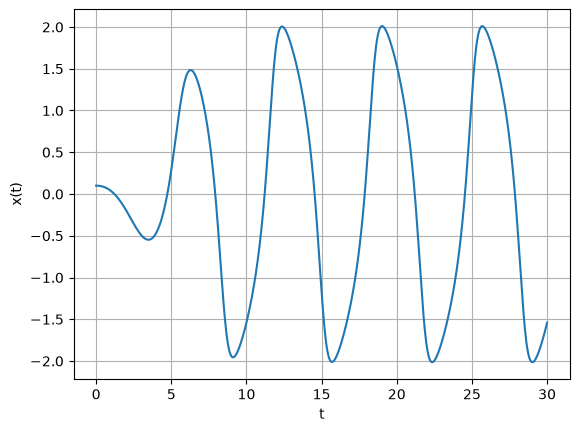

In [17]:
t = np.linspace(0, 30, 1000)
solution = sol.sol(t)

plt.plot(t, solution[0])
plt.xlabel('t')
plt.ylabel('x(t)')
plt.grid()
plt.show()

Колебания не затухают. Сначала их амплитуда увеличивается, но не растёт неограниченно.
После переходного процесса устанавливаются устойчивые колебания примерно постоянной амплитуды.

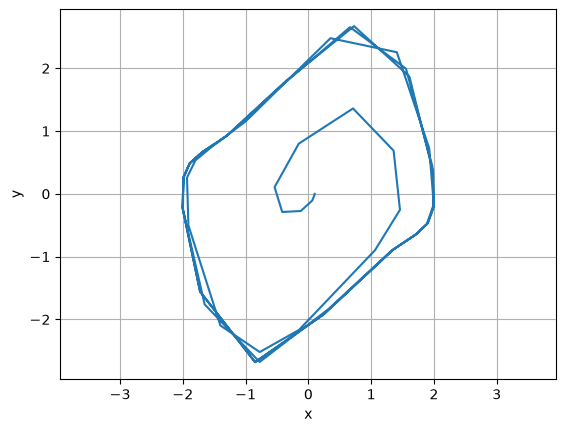

In [18]:
plt.plot(sol.y[0], sol.y[1])
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.grid()
plt.show()

Фазовая траектория сначала удаляется от положения равновесия, а затем приближается к замкнутой кривой.

Это показывает, что после переходного процесса решение выходит на устойчивый периодический режим.

# Зависимость от начального условия

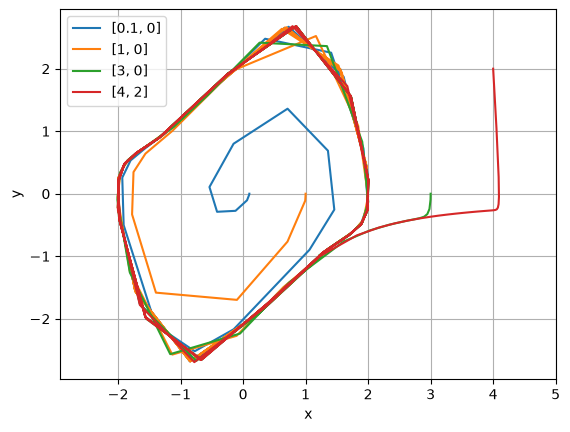

In [19]:
initial_conditions = [
    [0.1, 0],
    [1, 0],
    [3, 0],
    [4, 2]
]

for x0 in initial_conditions:
    sol = solve_ivp(
        vdf,
        t_span,
        x0,
        args=(mu_value,),
        dense_output=True
    )

    plt.plot(sol.y[0], sol.y[1], label=str(x0))

plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.grid()
plt.legend()
plt.show()

Траектории, начинающиеся близко к нулю, постепенно удаляются от положения равновесия и приближаются к замкнутой кривой.
Траектории, начинающиеся далеко от нуля, также приближаются к этой кривой, но с внешней стороны.
Таким образом, при больших $t$ решения с различными начальными условиями приближаются к одной и той же замкнутой траектории.

#  Предельный цикл

Траектории, начинающиеся из разных начальных условий, со временем приближаются к одной и той же замкнутой кривой.
Это позволяет предположить, что система Ван-дер-Поля имеет устойчивый предельный цикл.

# Дополнительное задание

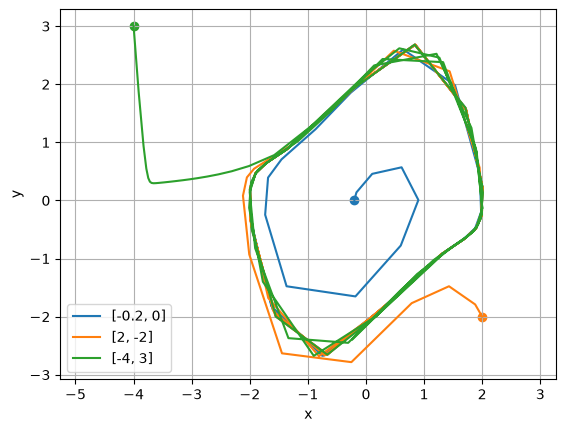

In [20]:
initial_conditions = [
    [-0.2, 0],
    [2, -2],
    [-4, 3]
]

for x0 in initial_conditions:
    sol = solve_ivp(
        vdf,
        t_span,
        x0,
        args=(mu_value,),
        dense_output=True
    )

    plt.plot(sol.y[0], sol.y[1], label=str(x0))
    plt.scatter(x0[0], x0[1])

plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.grid()
plt.legend()
plt.show()

Несмотря на разные начальные условия, все три траектории со временем приближаются к одной и той же замкнутой кривой.
Начальное условие влияет на переходный процесс, но в рассмотренных случаях не меняет долгосрочное поведение системы.
Таким образом, полученный результат подтверждает предположение о наличии устойчивого предельного цикла.